# 03. 탐색적 데이터 분석 (EDA)

| 항목 | 내용 |
|---|---|
| 목적 | 기술통계에서 넘어온 질문을 확인한다 — **달력 효과를 걷어내도 기상 효과가 남는가, 어디서·누구에게서 나오는가, 업종마다 다른가** |
| 입력 | `data/processed/` (01 전처리 산출물) |
| 출력 | 노트북 내 표·그림, EDA 요약표 `data/processed/eda_effect_group.parquet` (피해 예측 단계 참고용) |
| 브랜치 | `ana-eda` |

**진행 순서**
1. 환경 설정
2. 분석 방법 — 같은 주 안에서 비교하기 (주 고정효과)
3. 단순 비교의 함정: 폭염일 매출은 왜 높게 나왔나
4. 기상 효과 (달력 통제 후) — 지역 전체
5. 비는 언제·누구에게 피해를 주나 — 강수량 구간, 시간대, 평일/휴일, 고객 출신
6. 업종별 기상 반응 — **가설 3**
7. 겨울 기상 사건 분석 — 눈 온 날 전후 비교
8. 피해 금액 vs 피해율 — **가설 1·2**의 탐색
9. 기상 변수 간 상관 — 데이터 엔지니어링 필요성 판단
10. 정리

## 1. 환경 설정

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:,.2f}'.format)

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROC = ROOT / 'data' / 'processed'
load = lambda name: pd.read_parquet(PROC / f'{name}.parquet')

INK, INK2, GRID, SURFACE = '#0b0b0b', '#52514e', '#e4e3df', '#fcfcfb'
REGION_COLOR = {'강남구': '#2a78d6', '춘천시': '#eb6834'}
NEG, POS, MID = '#e34948', '#2a78d6', '#f0efec'
DIV = LinearSegmentedColormap.from_list('div_red_blue', ['#c43a3a', '#e34948', '#f2a3a2', MID, '#9ec5f4', '#2a78d6', '#1c5cab'])
plt.rcParams.update({
    'font.family': 'Malgun Gothic', 'axes.unicode_minus': False, 'figure.dpi': 110,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': GRID, 'axes.labelcolor': INK2, 'xtick.color': INK2, 'ytick.color': INK2,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlecolor': INK, 'axes.titlelocation': 'left',
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False, 'lines.linewidth': 2,
    'legend.frameon': False, 'legend.fontsize': 9,
})
REGIONS = ['강남구', '춘천시']
EOK = 1e8

## 2. 분석 방법 — 같은 주 안에서 비교하기

기술통계에서 매출 변동의 대부분이 **요일·연휴·휴가철**에서 나온다는 것을 확인했다. 그래서 기상 효과는 다음 회귀로 본다.

$$\log(\text{매출}+1) = \underbrace{\beta_1\,\text{폭염} + \beta_2\,\text{강수 구간} + \beta_3\,\text{눈} + \beta_4\,\text{한파}}_{\text{기상}} + \underbrace{\text{요일} + \text{공휴일} + \text{월급주간}}_{\text{달력}} + \underbrace{\text{주(week) 고정효과}}_{\text{계절·성수기}}$$

- **주 고정효과**: 같은 주(7일) 안에서 날씨가 다른 날끼리 비교한다. 휴가철·추석·연말 같은 '그 주 전체의 분위기'가 걷힌다.
- **효과(%)** = $e^{\beta} - 1$. 예) −0.07 → 약 −6.8%
- **표준오차**: Newey-West(7일) — 인접한 날의 오차가 서로 비슷한 점(자기상관)을 반영
- **다중검정**: 업종·지역별로 많은 검정을 하므로 Benjamini-Hochberg FDR로 보정 (q < 0.05)
- 기준(0)은 **체감 30℃ 미만 · 비 없음 · 눈·한파 아님** 인 날이다.

| 기상 변수 | 정의 |
|---|---|
| `heat_30_33` / `heat_33` | 일최고 체감온도 30~33℃ / 33℃ 이상 |
| `rain_light` / `rain_mid` / `rain_heavy` | 일강수량 0~5 / 5~30 / 30mm 이상 |
| `snow` | 신적설 0.5cm 이상 |
| `cold` | 일최저기온 −12℃ 이하 (춘천만 해당) |

In [2]:
TERMS = {'heat_30_33': '폭염 30~33℃', 'heat_33': '폭염 33℃~', 'rain_light': '비 약(0~5mm)',
         'rain_mid': '비 보통(5~30mm)', 'rain_heavy': '비 강(30mm~)', 'snow': '눈', 'cold': '한파'}
CONTROLS = 'C(dow) + is_holiday + is_payday_week + C(week)'

def prep(df, feels='feels_like_max', rain='rain_sum'):
    df = df.copy()
    df['log_amt'] = np.log1p(df['amount'])
    df['week'] = df['date'].dt.isocalendar().week.astype(int)
    df['heat_30_33'] = df[feels].between(30, 33, inclusive='left').astype(int)
    df['heat_33'] = (df[feels] >= 33).astype(int)
    df['rain_light'] = ((df[rain] > 0) & (df[rain] < 5)).astype(int)
    df['rain_mid'] = ((df[rain] >= 5) & (df[rain] < 30)).astype(int)
    df['rain_heavy'] = (df[rain] >= 30).astype(int)
    df['snow'] = df['snow_day'].astype(int)
    df['cold'] = df['cold_day'].astype(int)
    for c in ['is_holiday', 'is_payday_week']:
        df[c] = df[c].astype(int)
    return df

def fit(data, terms=TERMS, controls=CONTROLS, info=None, extra=''):
    """한 그룹을 추정해 기상 항의 효과(%)를 행으로 반환. 변동이 없는 항(예: 강남 한파)은 뺀다."""
    data = data.sort_values('date')
    use = [t for t in terms if data[t].nunique() > 1]
    res = smf.ols(f"log_amt ~ {' + '.join(use)}{extra} + {controls}", data=data).fit(
        cov_type='HAC', cov_kwds={'maxlags': 7})
    rows = []
    for t in use:
        b, se = res.params[t], res.bse[t]
        rows.append({**(info or {}), 'term': terms[t], 'n_days': int(data.loc[data[t] == 1, 'date'].nunique()),
                     'effect_pct': (np.exp(b) - 1) * 100, 'ci_low': (np.exp(b - 1.96 * se) - 1) * 100,
                     'ci_high': (np.exp(b + 1.96 * se) - 1) * 100, 'p_value': res.pvalues[t], 'coef': b, 'se': se})
    return rows

def run(df, by, **kw):
    rows = []
    for key, g in df.groupby(by, observed=True):
        key = key if isinstance(key, tuple) else (key,)
        rows += fit(g, info=dict(zip(by, key)), **kw)
    out = pd.DataFrame(rows)
    out['q_value'] = multipletests(out['p_value'], method='fdr_bh')[1]
    out['sig'] = out['q_value'] < 0.05
    return out

def total(df, keys):
    """업종을 합친 지역 전체 매출 (기상·달력 컬럼은 날짜·지역 단위라 첫 값 사용)."""
    other = [c for c in df.columns if c not in keys + ['amount', 'count', 'n_cells', 'industry_group', 'industry']]
    return df.groupby(keys, observed=True).agg({'amount': 'sum', **{c: 'first' for c in other}}).reset_index()

daily = prep(load('analysis_daily_group'))
tot = prep(total(load('analysis_daily_group'), ['date', 'region']))
print('일 단위 업종대분류', daily.shape, '| 지역 전체', tot.shape)

일 단위 업종대분류 (5520, 60) | 지역 전체 (368, 57)


## 3. 단순 비교의 함정: 폭염일 매출은 왜 높게 나왔나

같은 기상 효과를 **통제 수준을 높여 가며** 세 번 추정한다.
1. 통제 없음 (단순 평균 비교)
2. 월 + 요일 통제
3. **주 + 요일 + 공휴일 + 월급주간 통제** (이 노트북의 기본식)

In [3]:
specs = {'① 통제 없음': '1', '② 월 + 요일': 'C(month) + C(dow)', '③ 주 + 요일 + 공휴일': CONTROLS}
naive = pd.concat([run(tot, ['region'], controls=c).assign(spec=name) for name, c in specs.items()])
view = naive[naive['term'].isin(['폭염 33℃~', '폭염 30~33℃', '비 강(30mm~)', '비 보통(5~30mm)'])]
piv = view.pivot_table(index=['region', 'term'], columns='spec', values='effect_pct').round(1)
piv

spec                 ① 통제 없음  ② 월 + 요일  ③ 주 + 요일 + 공휴일
region term                                           
강남구    비 강(30mm~)      -5.10     -5.50           -1.90
       비 보통(5~30mm)    -6.70     -6.60           -3.30
       폭염 30~33℃       -5.40     -2.20           -0.10
       폭염 33℃~          1.40      2.50            2.00
춘천시    비 강(30mm~)      -7.30     -9.80           -7.20
       비 보통(5~30mm)    -7.30     -8.00           -5.60
       폭염 30~33℃       -2.10      0.40            2.40
       폭염 33℃~          1.70      1.80            2.20

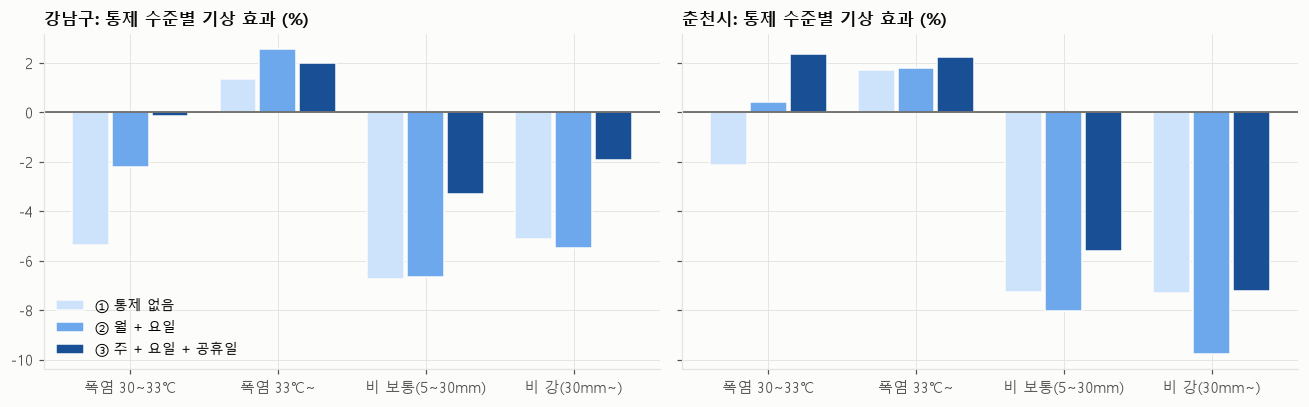

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
terms_show = ['폭염 30~33℃', '폭염 33℃~', '비 보통(5~30mm)', '비 강(30mm~)']
shades = {'① 통제 없음': '#cde2fb', '② 월 + 요일': '#6da7ec', '③ 주 + 요일 + 공휴일': '#184f95'}
for ax, r in zip(axes, REGIONS):
    x = np.arange(len(terms_show))
    for k, (spec, color) in enumerate(shades.items()):
        d = view[(view['region'] == r) & (view['spec'] == spec)].set_index('term').reindex(terms_show)
        ax.bar(x + (k - 1) * 0.27, d['effect_pct'], width=0.25, color=color, label=spec, edgecolor=SURFACE)
    ax.axhline(0, color=INK2, lw=1)
    ax.set_xticks(x, terms_show)
    ax.set_title(f'{r}: 통제 수준별 기상 효과 (%)', fontsize=11)
axes[0].legend(loc='lower left')
fig.tight_layout()

In [5]:
# 폭염일은 어느 주에 몰려 있나
w = tot.drop_duplicates(['date', 'region'])
hw = w.groupby(['region', 'week']).agg(폭염일=('heat_33', 'sum'), 시작일=('date', 'min'))
top = hw[hw['폭염일'] > 0].reset_index()
print('폭염일(체감 33℃↑)이 있는 주:')
top.pivot(index='시작일', columns='region', values='폭염일').fillna(0).astype(int).T

폭염일(체감 33℃↑)이 있는 주:


시작일,2025-07-01,2025-07-07,2025-07-21,2025-07-28,2025-08-04,2025-08-18,2025-08-25
region,,,,,,,
강남구,1,5,5,6,1,5,2
춘천시,0,3,6,5,0,2,3


**해석**
- **폭염 효과는 성수기 효과였다.** 강남 '폭염 30~33℃'는 통제가 없을 때 −5.4%였는데 주 단위 통제 후 −0.1%로 사라진다. 33℃ 이상은 어느 단계에서도 +2% 안팎이고 유의하지 않다.
- 폭염일은 7월 초~8월 말의 몇 주에 몰려 있다. 그래서 월 단위 통제로는 휴가철 안의 주별 차이를 걷어내지 못하고, **주 고정효과**가 필요하다.
- 강남의 강한 비 효과도 단순 비교 −5.1%에서 −1.9%로 줄었다. 반면 **춘천의 강한 비 효과(−7.2%)는 통제를 높여도 그대로 남는다.**

## 4. 기상 효과 (달력 통제 후) — 지역 전체

In [6]:
eff_tot = run(tot, ['region'])
eff_tot[['region', 'term', 'n_days', 'effect_pct', 'ci_low', 'ci_high', 'p_value', 'q_value', 'sig']].round(3)

,region,term,n_days,effect_pct,ci_low,ci_high,p_value,q_value,sig
0,강남구,폭염 30~33℃,35,-0.14,-4.09,3.98,0.95,0.95,False
1,강남구,폭염 33℃~,25,1.98,-3.29,7.54,0.47,0.74,False
2,강남구,비 약(0~5mm),29,2.08,-0.37,4.58,0.10,0.30,False
3,강남구,비 보통(5~30mm),25,-3.30,-7.23,0.81,0.11,0.30,False
4,강남구,비 강(30mm~),13,-1.93,-5.25,1.52,0.27,0.58,False
5,강남구,눈,2,-1.99,-11.12,8.07,0.69,0.74,False
6,춘천시,폭염 30~33℃,34,2.37,-3.04,8.07,0.40,0.74,False
7,춘천시,폭염 33℃~,19,2.23,-4.50,9.42,0.53,0.74,False
8,춘천시,비 약(0~5mm),25,-0.64,-3.65,2.48,0.69,0.74,False
9,춘천시,비 보통(5~30mm),19,-5.62,-9.53,-1.54,0.01,0.05,True


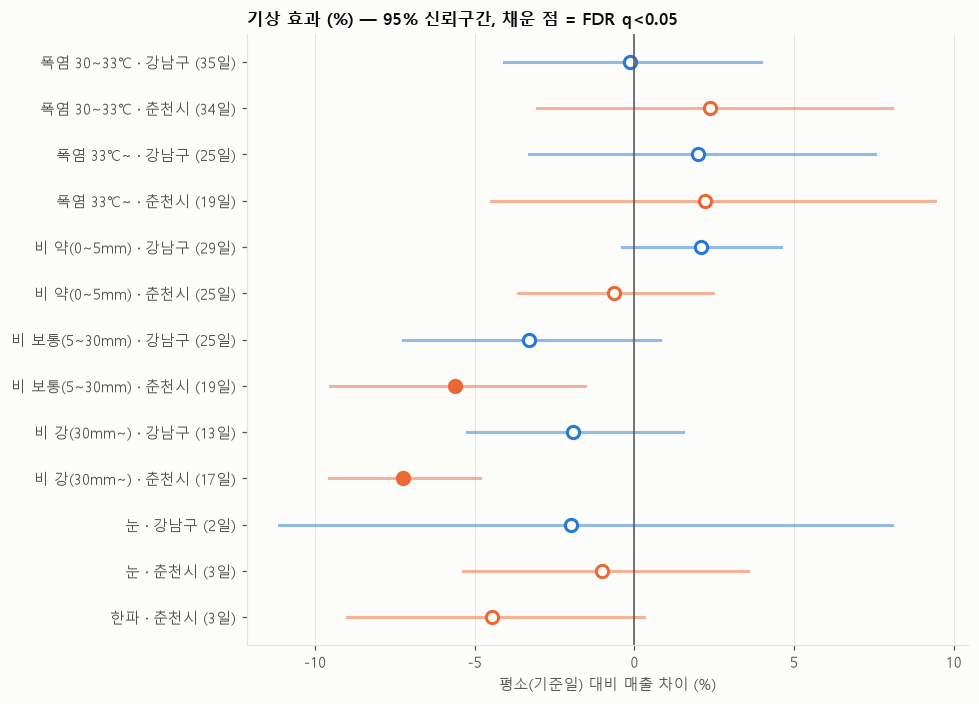

In [7]:
def forest(ax, d, title):
    d = d.reset_index(drop=True)
    y = np.arange(len(d))[::-1]
    for i, row in d.iterrows():
        c = REGION_COLOR[row['region']]
        ax.plot([row['ci_low'], row['ci_high']], [y[i], y[i]], color=c, lw=2, alpha=0.5)
        ax.plot(row['effect_pct'], y[i], 'o', ms=8, color=c if row['sig'] else SURFACE, mec=c, mew=2)
    ax.axvline(0, color=INK2, lw=1)
    ax.set_yticks(y, d['term'] + ' · ' + d['region'] + ' (' + d['n_days'].astype(str) + '일)')
    ax.set_title(title, fontsize=11)
    ax.grid(axis='y', visible=False)

order_terms = list(TERMS.values())
d = eff_tot.assign(o=eff_tot['term'].map(order_terms.index)).sort_values(['o', 'region'])
fig, ax = plt.subplots(figsize=(9, 6.5))
forest(ax, d, '기상 효과 (%) — 95% 신뢰구간, 채운 점 = FDR q<0.05')
ax.set_xlabel('평소(기준일) 대비 매출 차이 (%)')
fig.tight_layout()

**해석**
- 지역 전체 매출에서 통계적으로 확실한 기상 효과는 **춘천의 비** 하나다: 보통 비(5~30mm) **−5.6%**, 강한 비(30mm↑) **−7.2%**.
- 강남의 비 효과는 같은 방향(−2~−3%)이지만 신뢰구간이 0을 포함한다. 폭염은 두 지역 모두 효과가 없다.
- 눈(2~3일)·한파(3일)는 신뢰구간이 넓어 지역 전체로는 판단할 수 없다 → 업종별(6절)·사건별(7절)로 본다.

## 5. 비는 언제·누구에게 피해를 주나
### 5-1. 강수량에 따라 피해가 커지나 (용량-반응)
강수량을 더 잘게 나눠, 비가 많을수록 매출이 더 줄어드는지 본다.

,region,term,n_days,effect_pct,ci_low,ci_high,q_value
3,강남구,0~1mm,20,3.61,1.24,6.04,0.03
4,강남구,1~5mm,9,-1.39,-5.53,2.93,0.71
5,강남구,5~15mm,13,-2.04,-5.13,1.15,0.39
6,강남구,15~30mm,12,-5.67,-11.48,0.52,0.27
7,강남구,30~60mm,8,-1.45,-5.66,2.95,0.71
8,강남구,60mm~,5,-4.29,-10.44,2.28,0.39
13,춘천시,0~1mm,15,0.03,-3.88,4.10,0.99
14,춘천시,1~5mm,10,-2.12,-5.27,1.14,0.39
15,춘천시,5~15mm,14,-3.93,-7.20,-0.54,0.11
16,춘천시,15~30mm,5,-14.83,-29.34,2.67,0.29


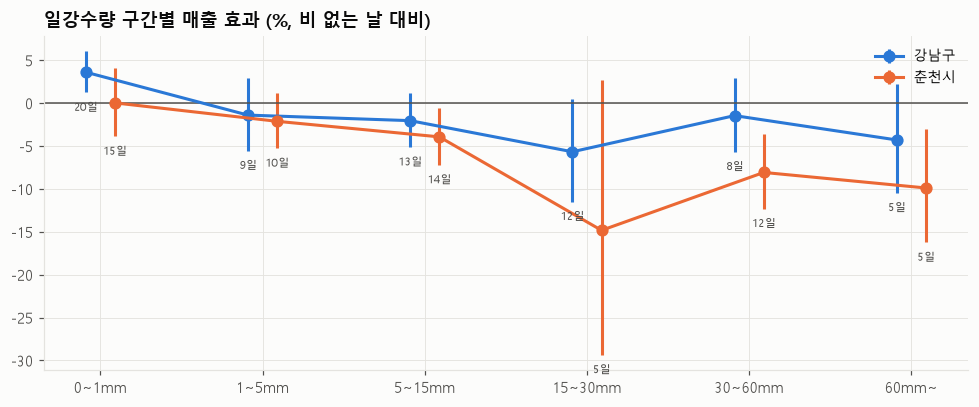

In [8]:
RAIN_FINE = {'r_0_1': '0~1mm', 'r_1_5': '1~5mm', 'r_5_15': '5~15mm', 'r_15_30': '15~30mm', 'r_30_60': '30~60mm', 'r_60': '60mm~'}
cuts = [(0, 1), (1, 5), (5, 15), (15, 30), (30, 60), (60, 1e9)]
t2 = tot.copy()
for (lo, hi), k in zip(cuts, RAIN_FINE):
    t2[k] = ((t2['rain_sum'] > lo if lo == 0 else t2['rain_sum'] >= lo) & (t2['rain_sum'] < hi)).astype(int)
terms2 = {**{k: v for k, v in TERMS.items() if k.startswith('heat') or k in ('snow', 'cold')}, **RAIN_FINE}
dose = run(t2, ['region'], terms=terms2)
dose = dose[dose['term'].isin(RAIN_FINE.values())]

fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(RAIN_FINE))
for k, r in enumerate(REGIONS):
    d = dose[dose['region'] == r].set_index('term').reindex(RAIN_FINE.values())
    xx = x + (k - 0.5) * 0.18
    ax.errorbar(xx, d['effect_pct'], yerr=[d['effect_pct'] - d['ci_low'], d['ci_high'] - d['effect_pct']],
                fmt='o-', color=REGION_COLOR[r], ms=7, capsize=0, lw=2, label=r)
    for xi, (_, row) in zip(xx, d.iterrows()):
        ax.annotate(f"{row['n_days']}일", (xi, row['ci_low']), textcoords='offset points', xytext=(0, -12),
                    ha='center', fontsize=7, color=INK2)
ax.axhline(0, color=INK2, lw=1)
ax.set_xticks(x, RAIN_FINE.values())
ax.set_title('일강수량 구간별 매출 효과 (%, 비 없는 날 대비)')
ax.legend()
fig.tight_layout()
dose[['region', 'term', 'n_days', 'effect_pct', 'ci_low', 'ci_high', 'q_value']].round(2)

### 5-2. 비가 온 시간대에 따라 다른가
카드 데이터1은 6시간 구간별 매출이 있다. 각 시간대 매출을 **그 시간대에 내린 비**와 **그날 다른 시간대에 내린 비**로 나눠 본다.
- `slot_rain`: 해당 6시간에 1mm 이상 비 / `other_rain`: 같은 날 다른 시간에 5mm 이상 비

time_slot         00_05  06_11  12_17  18_23
region term                                 
강남구    그 시간대에 비   -1.30  -2.80  -4.70  -5.30
       다른 시간대에 비  -3.60   1.30  -0.70  -2.20
       폭염 33℃~    -3.20   2.00   1.70   2.90
춘천시    그 시간대에 비   -5.90  -8.00  -8.20 -10.40
       다른 시간대에 비  -3.70  -1.10  -2.90  -2.90
       폭염 33℃~    -2.90   4.30  -1.90  -0.80

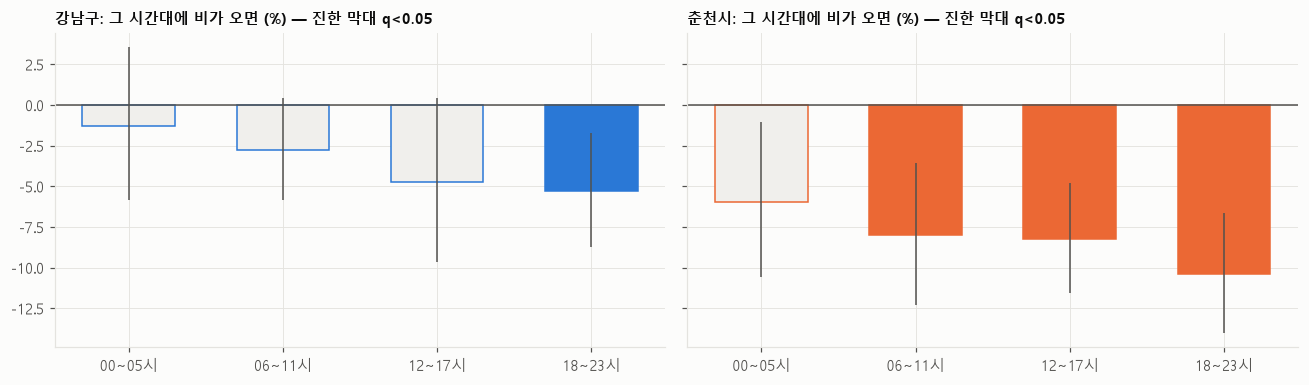

In [9]:
slot = load('analysis_slot_group')
st = total(slot, ['date', 'time_slot', 'region'])
st = prep(st)
st['slot_rain'] = (st['slot_rain_sum'] >= 1).astype(int)
st['other_rain'] = ((st['rain_sum'] - st['slot_rain_sum']) >= 5).astype(int)
slot_terms = {'slot_rain': '그 시간대에 비', 'other_rain': '다른 시간대에 비', 'heat_33': '폭염 33℃~'}
slot_eff = run(st, ['region', 'time_slot'], terms=slot_terms)
sv = slot_eff.pivot_table(index=['region', 'term'], columns='time_slot', values='effect_pct').round(1)
display(sv)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, r in zip(axes, REGIONS):
    d = slot_eff[(slot_eff['region'] == r) & (slot_eff['term'] == '그 시간대에 비')].set_index('time_slot')
    x = np.arange(len(d))
    colors = [REGION_COLOR[r] if s else MID for s in d['sig']]
    ax.bar(x, d['effect_pct'], color=colors, edgecolor=REGION_COLOR[r], width=0.6)
    ax.errorbar(x, d['effect_pct'], yerr=[d['effect_pct'] - d['ci_low'], d['ci_high'] - d['effect_pct']],
                fmt='none', ecolor=INK2, lw=1)
    ax.axhline(0, color=INK2, lw=1)
    ax.set_xticks(x, ['00~05시', '06~11시', '12~17시', '18~23시'])
    ax.set_title(f'{r}: 그 시간대에 비가 오면 (%) — 진한 막대 q<0.05', fontsize=10)
fig.tight_layout()

### 5-3. 평일 비 vs 휴일 비
강남은 평일(직장인), 춘천은 휴일(방문객) 상권이었다. 비(5mm 이상)의 효과가 평일과 휴일에 다른지 본다.

In [10]:
t3 = tot.copy()
t3['rain5'] = (t3['rain_sum'] >= 5).astype(int)
t3['is_offday'] = t3['is_offday'].astype(int)
t3['rain5_weekday'] = t3['rain5'] * (1 - t3['is_offday'])
t3['rain5_offday'] = t3['rain5'] * t3['is_offday']
off_terms = {'rain5_weekday': '평일에 비(5mm↑)', 'rain5_offday': '휴일에 비(5mm↑)', 'heat_33': '폭염 33℃~'}
off_eff = run(t3, ['region'], terms=off_terms)
off_eff[['region', 'term', 'n_days', 'effect_pct', 'ci_low', 'ci_high', 'q_value']].round(2)

,region,term,n_days,effect_pct,ci_low,ci_high,q_value
0,강남구,평일에 비(5mm↑),25,-3.06,-5.51,-0.55,0.04
1,강남구,휴일에 비(5mm↑),13,-4.11,-11.08,3.41,0.33
2,강남구,폭염 33℃~,25,1.92,-1.35,5.31,0.33
3,춘천시,평일에 비(5mm↑),23,-6.91,-9.30,-4.45,0.00
4,춘천시,휴일에 비(5mm↑),13,-5.85,-10.49,-0.97,0.04
5,춘천시,폭염 33℃~,19,-0.22,-3.10,2.75,0.88


### 5-4. 현지 고객 vs 외지 고객
카드 데이터2로 고객 거주지(가맹점과 같은 시도 = 현지, 다른 시도 = 외지)별 반응을 비교한다.

customer_origin         외지    현지
region term                     
강남구    비 강(30mm~)    -2.10 -1.70
       비 보통(5~30mm)  -3.60 -3.20
       폭염 33℃~        0.80  3.20
춘천시    비 강(30mm~)   -20.10 -3.90
       비 보통(5~30mm)  -5.00 -6.30
       폭염 33℃~       -1.80  3.30

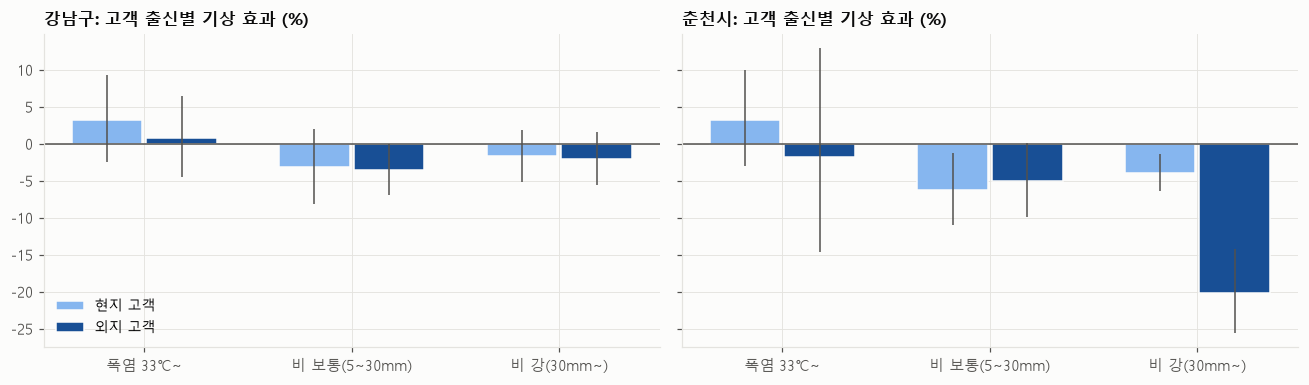

In [11]:
origin = load('analysis_origin_group')
org = origin[origin['customer_origin'] != '미상']
ot = prep(total(org, ['date', 'region', 'customer_origin']))
org_eff = run(ot, ['region', 'customer_origin'])
ov = org_eff[org_eff['term'].isin(['폭염 33℃~', '비 보통(5~30mm)', '비 강(30mm~)'])]
display(ov.pivot_table(index=['region', 'term'], columns='customer_origin', values='effect_pct').round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, r in zip(axes, REGIONS):
    d = ov[ov['region'] == r]
    tl = ['폭염 33℃~', '비 보통(5~30mm)', '비 강(30mm~)']
    x = np.arange(len(tl))
    for k, (o, color) in enumerate([('현지', '#86b6ef'), ('외지', '#184f95')]):
        dd = d[d['customer_origin'] == o].set_index('term').reindex(tl)
        ax.bar(x + (k - 0.5) * 0.36, dd['effect_pct'], width=0.34, color=color, label=f'{o} 고객', edgecolor=SURFACE)
        ax.errorbar(x + (k - 0.5) * 0.36, dd['effect_pct'], yerr=[dd['effect_pct'] - dd['ci_low'], dd['ci_high'] - dd['effect_pct']],
                    fmt='none', ecolor=INK2, lw=1)
    ax.axhline(0, color=INK2, lw=1)
    ax.set_xticks(x, tl)
    ax.set_title(f'{r}: 고객 출신별 기상 효과 (%)', fontsize=11)
axes[0].legend(loc='lower left')
fig.tight_layout()

**5절 해석**
- **용량-반응**: 춘천은 비가 많을수록 감소가 커진다 (5~15mm −3.9% → 30~60mm −8.1% → 60mm↑ −9.9%). 강남은 일관된 경향이 약하다. 이슬비(0~1mm) 날 강남 +3.6%는 실내 업종으로의 이동 또는 우연일 수 있다.
- **시간대**: 비는 **내리는 그 시간대**의 매출을 깎는다. 춘천은 시간대마다 −6~−10%이고, 저녁(18~23시)이 −10.4%로 가장 크다. 같은 날 다른 시간대에 온 비의 영향은 작다 → 하루 강수 합계보다 **'언제 왔나'**가 중요하다 (데이터 엔지니어링 후보).
- **평일/휴일**: 강남은 평일 비만 유의(−3.1%)하고, 춘천은 평일(−6.9%)·휴일(−5.9%) 모두 감소한다.
- **고객 출신**: 춘천에 강한 비가 오면 **외지 고객 매출이 −20.1%**로 현지 고객(−3.9%)의 약 5배 줄어든다. 강남은 차이가 없다. **춘천 호우 피해의 핵심 경로는 방문객 이탈**이다.

## 6. 업종별 기상 반응 — 가설 3

> **가설 3**: 기상 유형(폭염·비·눈·한파)에 따라 업종별 피해의 방향과 크기가 다르다.

### 6-1. 업종대분류 × 기상 유형 (지역별)

In [12]:
eff_grp = run(daily, ['region', 'industry_group'])
eff_grp.to_parquet(PROC / 'eda_effect_group.parquet', index=False)
print(f"검정 {len(eff_grp)}개 중 FDR q<0.05: {eff_grp['sig'].sum()}개")
sig = eff_grp[eff_grp['sig']].sort_values('effect_pct')
sig[['region', 'industry_group', 'term', 'n_days', 'effect_pct', 'ci_low', 'ci_high', 'q_value']].round(3)

검정 195개 중 FDR q<0.05: 25개


,region,industry_group,term,n_days,effect_pct,ci_low,ci_high,q_value
150,춘천시,여가·오락,비 강(30mm~),17,-37.72,-43.90,-30.86,0.00
102,춘천시,교육,눈,3,-32.22,-42.37,-20.27,0.00
172,춘천시,의류·잡화,눈,3,-17.86,-26.15,-8.65,0.01
187,춘천시,카페·디저트,한파,3,-17.72,-27.78,-6.27,0.03
144,춘천시,식료품소매,눈,3,-15.18,-23.22,-6.30,0.01
170,춘천시,의류·잡화,비 보통(5~30mm),19,-14.12,-22.98,-4.23,0.05
145,춘천시,식료품소매,한파,3,-13.28,-19.34,-6.76,0.00
171,춘천시,의류·잡화,비 강(30mm~),17,-10.38,-15.55,-4.90,0.01
17,강남구,교통·자동차,눈,2,-9.87,-14.35,-5.16,0.00
185,춘천시,카페·디저트,비 강(30mm~),17,-9.51,-12.75,-6.15,0.00


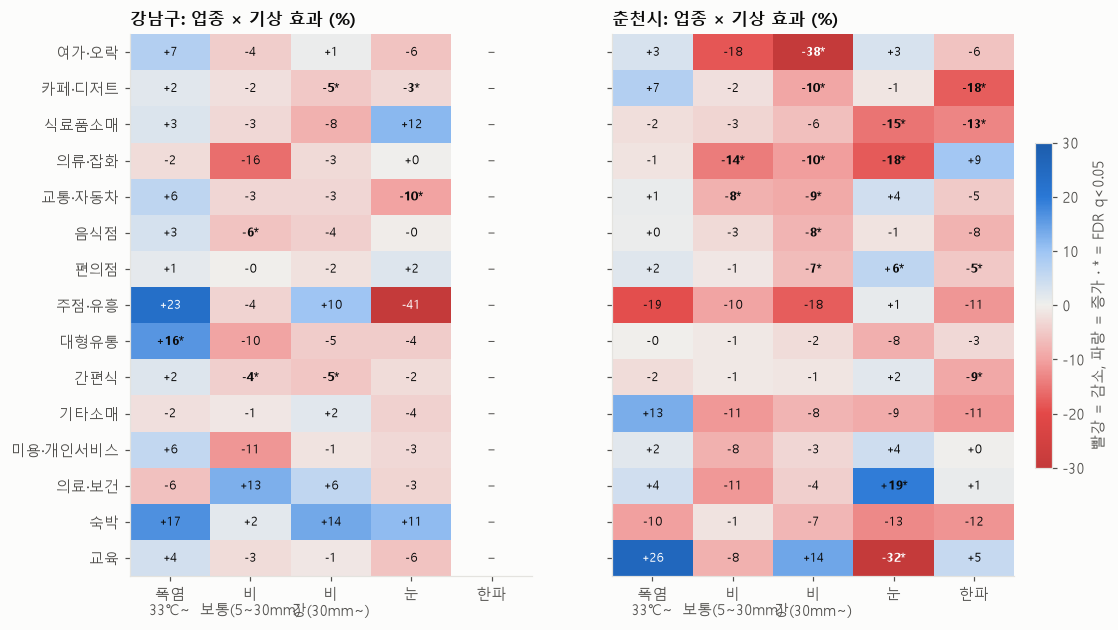

In [13]:
show_terms = ['폭염 33℃~', '비 보통(5~30mm)', '비 강(30mm~)', '눈', '한파']
grp_order = (eff_grp[eff_grp['term'] == '비 강(30mm~)'].groupby('industry_group')['effect_pct'].mean().sort_values().index)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 6.4), sharey=True)
for ax, r in zip(axes, REGIONS):
    e = eff_grp[eff_grp['region'] == r]
    m = e.pivot(index='industry_group', columns='term', values='effect_pct').reindex(index=grp_order, columns=show_terms)
    s = e.pivot(index='industry_group', columns='term', values='sig').reindex(index=grp_order, columns=show_terms)
    im = ax.imshow(m.values, cmap=DIV, vmin=-30, vmax=30, aspect='auto')
    ax.set_xticks(range(len(show_terms)), [t.replace(' ', '\n', 1) for t in show_terms])
    ax.set_yticks(range(len(m)), m.index)
    ax.grid(False)
    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            v = m.values[i, j]
            if pd.notna(v):
                ax.text(j, i, f"{v:+.0f}{'*' if s.values[i, j] else ''}", ha='center', va='center', fontsize=8,
                        color='white' if abs(v) > 20 else INK, fontweight='bold' if s.values[i, j] else 'normal')
            else:
                ax.text(j, i, '–', ha='center', va='center', fontsize=8, color=INK2)
    ax.set_title(f'{r}: 업종 × 기상 효과 (%)', fontsize=11)
cb = fig.colorbar(im, ax=axes, shrink=0.6, pad=0.02)
cb.set_label('빨강 = 감소, 파랑 = 증가 · * = FDR q<0.05', color=INK2)

**해석 — 가설 3**
- 195개 검정 중 25개가 유의하다. **비로 인한 감소는 대부분 춘천 업종**이다: 여가·오락 **−37.7%**, 의류·잡화 −10~−14%, 카페·디저트 −9.5%, 교통·자동차 −8~−9%, 음식점 −7.5%, 편의점 −6.7%. 강남은 음식점(보통 비 −5.8%)·간편식·카페·디저트(강한 비 −5%) 정도다.
- **폭염은 업종에 따라 반대로 작용한다.** 강남 대형유통은 폭염(33℃↑)에 **+16.1%**로 늘었다. 더운 날 냉방된 실내 대형 매장으로 소비가 **이동**한 것이다. 지역 전체로 폭염 효과가 0인 것은 '모두 무관'이 아니라 **늘어난 업종과 줄어든 업종이 상쇄된 결과**일 수 있다.
- **같은 업종도 기상 유형에 따라 방향이 바뀐다.** 예) 춘천 편의점은 강한 비 −6.7%, 눈 +6.0%. 춘천 의료·보건은 눈 +19%. 다만 눈·한파는 2~3일에 기반한 값이라 **방향 참고용**이다.
- → 가설 3("기상 유형에 따라 업종별 피해의 방향과 크기가 다르다")은 **데이터와 맞는 방향**이다. 피해 예측 모델은 기상 효과를 **업종별로 다르게** 허용해야 한다.

### 6-2. 세부 업종: 폭염에 강한 업종 vs 비에 약한 업종
업종대분류 안에서도 세부 업종(71개)마다 반응이 다를 수 있다. 0 채움(소액 미집계) 일수가 5% 이하인 세부 업종만 쓴다.
가로축 = 폭염(33℃↑) 효과, 세로축 = 강한 비(30mm↑) 효과. **사분면이 다르면 기상 유형에 따라 반응 방향이 바뀌는 업종**이다.

세부 업종 × 지역 130개, 검정 841개 중 q<0.05: 64개


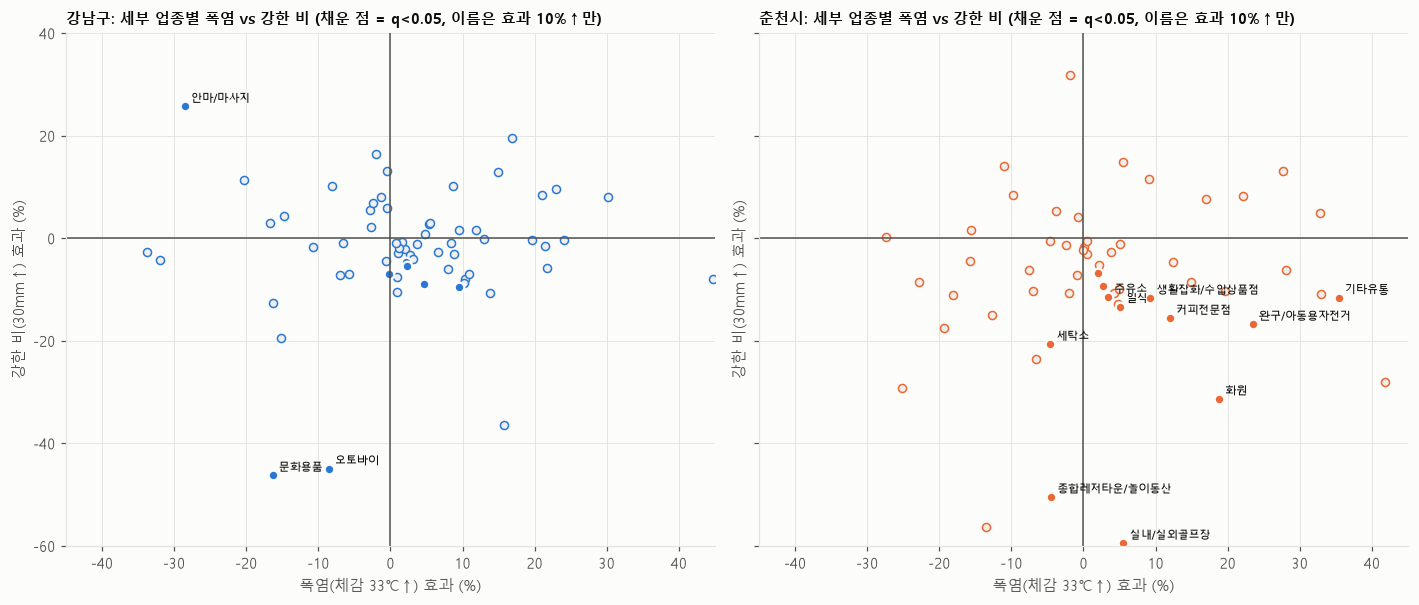

In [14]:
ind = load('analysis_daily_industry')
dense = ind.groupby(['region', 'industry'])['n_cells'].apply(lambda s: (s == 0).mean() <= 0.05)
ind = ind.set_index(['region', 'industry']).loc[dense[dense].index].reset_index()
ind = prep(ind)
eff_ind = run(ind, ['region', 'industry'], terms={k: TERMS[k] for k in ['heat_30_33', 'heat_33', 'rain_light', 'rain_mid', 'rain_heavy', 'snow', 'cold']})
wide = eff_ind.pivot_table(index=['region', 'industry'], columns='term', values=['effect_pct', 'sig']).reset_index()
wide.columns = ['region', 'industry'] + [f'{a}|{b}' for a, b in wide.columns[2:]]
print(f"세부 업종 × 지역 {len(wide)}개, 검정 {len(eff_ind)}개 중 q<0.05: {eff_ind['sig'].sum()}개")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), sharex=True, sharey=True)
for ax, r in zip(axes, REGIONS):
    d = wide[wide['region'] == r]
    x, y = d['effect_pct|폭염 33℃~'], d['effect_pct|비 강(30mm~)']
    sig_any = d['sig|폭염 33℃~'].astype(bool) | d['sig|비 강(30mm~)'].astype(bool)
    ax.scatter(x[~sig_any], y[~sig_any], s=28, color=MID, edgecolor=REGION_COLOR[r], linewidth=1)
    ax.scatter(x[sig_any], y[sig_any], s=40, color=REGION_COLOR[r], edgecolor=SURFACE, linewidth=1.5)
    for _, row in d[sig_any & ((x.abs() >= 10) | (y.abs() >= 10))].iterrows():
        ax.annotate(row['industry'], (row['effect_pct|폭염 33℃~'], row['effect_pct|비 강(30mm~)']),
                    textcoords='offset points', xytext=(4, 3), fontsize=7.5, color=INK)
    ax.axhline(0, color=INK2, lw=1); ax.axvline(0, color=INK2, lw=1)
    ax.set_xlabel('폭염(체감 33℃↑) 효과 (%)'); ax.set_ylabel('강한 비(30mm↑) 효과 (%)')
    ax.set_title(f'{r}: 세부 업종별 폭염 vs 강한 비 (채운 점 = q<0.05, 이름은 효과 10%↑만)', fontsize=10)
ax.set_xlim(-45, 45); ax.set_ylim(-60, 40)
fig.tight_layout()

In [15]:
cols = ['region', 'industry', 'effect_pct|폭염 33℃~', 'effect_pct|비 강(30mm~)', 'effect_pct|눈']
rev = wide[(wide['sig|폭염 33℃~'].astype(bool)) | (wide['sig|비 강(30mm~)'].astype(bool))][cols]
rev['방향'] = np.select([(rev['effect_pct|폭염 33℃~'] > 0) & (rev['effect_pct|비 강(30mm~)'] < 0),
                         (rev['effect_pct|폭염 33℃~'] < 0) & (rev['effect_pct|비 강(30mm~)'] > 0)],
                        ['폭염 ↑ / 비 ↓', '폭염 ↓ / 비 ↑'], '같은 방향')
print('폭염 또는 강한 비 효과가 유의한 세부 업종')
rev.sort_values(['region', '방향', 'effect_pct|비 강(30mm~)']).round(1)

폭염 또는 강한 비 효과가 유의한 세부 업종


,region,industry,effect_pct|폭염 33℃~,effect_pct|비 강(30mm~),effect_pct|눈,방향
15,강남구,문화용품,-16.30,-46.20,-33.80,같은 방향
36,강남구,오토바이,-8.50,-45.00,-8.90,같은 방향
47,강남구,제과점,-0.20,-7.00,-10.30,같은 방향
6,강남구,기타요식,9.60,-9.50,-2.70,폭염 ↑ / 비 ↓
50,강남구,주유소,4.70,-8.90,-15.10,폭염 ↑ / 비 ↓
59,강남구,패스트푸드,2.30,-5.30,-2.40,폭염 ↑ / 비 ↓
56,강남구,커피전문점,2.10,-4.60,-1.70,폭염 ↑ / 비 ↓
31,강남구,안마/마사지,-28.40,25.70,7.20,폭염 ↓ / 비 ↑
110,춘천시,종합레저타운/놀이동산,-4.40,-50.50,-2.00,같은 방향
88,춘천시,세탁소,-4.60,-20.70,-4.70,같은 방향


**해석**
- 세부 업종에서는 **'폭염에 늘고 비에 줄어드는'** 업종이 가장 많다: 커피전문점(춘천 폭염 +12% / 강한 비 −16%), 화원, 완구, 실내/실외골프장, 주유소, 기타요식 등. 날씨가 좋으면(비가 없으면) 외출 수요가 살아나는 업종들이다.
- 반대 방향(폭염에 줄고 비에 늘어남)은 강남 안마/마사지(−28% / +26%) 정도로 드물다.
- 비와 폭염 모두에 약한 업종도 있다: 강남 문화용품·오토바이, 춘천 종합레저타운/놀이동산·세탁소.
- 카드 업종 분류에는 '빙과'·'떡볶이' 같은 품목이 없지만, **커피전문점(차가운 음료·디저트)처럼 더위에 수요가 늘고 비에 줄어드는 업종**이 가설 3의 예시와 같은 구조를 보인다.
- 세부 업종 검정은 841개로 많아, 개별 결과는 **확정이 아니라 후보**로 본다. 피해 예측은 표본이 충분한 업종대분류 단위로 하고, 세부 업종은 사례 설명에 쓴다.

## 7. 겨울 기상 사건 분석 — 눈 온 날 전후 비교

눈·한파는 2~3일뿐이라 회귀 계수가 불안정하다. 대표 사건을 골라 **같은 요일의 앞뒤 2주 평균과 비교**한다 (공휴일 제외).

| 사건 | 지역 | 내용 |
|---|---|---|
| 2025-12-04(목) | 강남구 | 저녁 시간 3시간 신적설 5.1cm — 퇴근길 폭설 |
| 2025-12-23(화) | 춘천시 | 적설 6.4cm |

In [16]:
events = [('강남구', '2025-12-04'), ('춘천시', '2025-12-23')]
dg = load('analysis_daily_group')
sg = load('analysis_slot_group')
rows, slot_rows = [], []
for r, day in events:
    day = pd.Timestamp(day)
    refs = [day + pd.Timedelta(weeks=k) for k in (-2, -1, 1, 2)]
    refs = [d for d in refs if d <= pd.Timestamp('2025-12-31') and not dg.loc[dg['date'] == d, 'is_holiday'].any()]
    e = dg[(dg['region'] == r) & (dg['date'] == day)].set_index('industry_group')['amount']
    b = dg[(dg['region'] == r) & (dg['date'].isin(refs))].groupby('industry_group')['amount'].mean()
    rows.append(((e / b - 1) * 100).rename(f'{r} {day:%m-%d}'))
    es = sg[(sg['region'] == r) & (sg['date'] == day)].groupby('time_slot', observed=True)['amount'].sum()
    bs = sg[(sg['region'] == r) & (sg['date'].isin(refs))].groupby(['date', 'time_slot'], observed=True)['amount'].sum().groupby('time_slot', observed=True).mean()
    slot_rows.append(((es / bs - 1) * 100).rename(f'{r} {day:%m-%d}'))
    print(f"{r} {day:%Y-%m-%d} 비교일: {[f'{d:%m-%d}' for d in refs]} | 전체 매출 변화 {(e.sum() / b.sum() - 1) * 100:+.1f}%")
ev = pd.concat(rows, axis=1)
print('\n시간대별 매출 변화(%)')
display(pd.concat(slot_rows, axis=1).round(1).T)
print('업종별 매출 변화(%) — 같은 요일 앞뒤 2주 평균 대비')
ev.round(1).sort_values(ev.columns[0])

강남구 2025-12-04 비교일: ['11-20', '11-27', '12-11', '12-18'] | 전체 매출 변화 -10.2%
춘천시 2025-12-23 비교일: ['12-09', '12-16', '12-30'] | 전체 매출 변화 -6.8%

시간대별 매출 변화(%)


time_slot,00_05,06_11,12_17,18_23
강남구 12-04,-8.60,-9.80,-10.50,-10.00
춘천시 12-23,17.20,-7.20,-4.00,-13.40


업종별 매출 변화(%) — 같은 요일 앞뒤 2주 평균 대비


,강남구 12-04,춘천시 12-23
industry_group,,
주점·유흥,-65.00,32.30
교육,-25.40,-32.50
여가·오락,-21.20,-9.70
의료·보건,-15.40,9.00
식료품소매,-15.30,-23.20
간편식,-10.40,-4.00
기타소매,-10.00,-19.20
음식점,-9.70,-7.00
교통·자동차,-9.50,-7.40


**해석**
- **강남 12/4 퇴근길 폭설**: 전체 매출 −10.2%. 저녁 시간대만이 아니라 하루 종일 줄었다 (그날 최저 −9.4℃의 추위도 겹침). 업종별로는 **주점·유흥 −65%**, 교육 −25%, 여가·오락 −21%가 크게 줄었고, **숙박은 +24%**로 늘었다 (귀가하지 못한 수요로 추정).
- **춘천 12/23 적설 6.4cm**: 전체 −6.8%. 의류·잡화 −42%, 숙박 −43%, 교육 −33%, 식료품소매 −23%, 미용 −21%가 줄었다.
- 같은 '눈'이라도 **지역에 따라 숙박의 반응이 반대**다 (강남 + / 춘천 −). 강남 숙박은 발이 묶인 현지 수요, 춘천 숙박은 오지 못한 방문객 수요로 보인다 → 5-4절의 '외지 이탈' 경로와 같다.
- 사건 1~2개, 크리스마스·연말과 가까운 날짜라 **수치보다는 방향**을 보는 근거로 쓴다.

## 8. 피해 금액 vs 피해율 — 가설 1·2의 탐색

> **가설 1**: 같은 피해 금액이라도 업체 규모(월매출)에 따라 실제 타격은 다르다.
> **가설 2**: 그렇다면 피해 금액이 같은 업체에 동일한 지원을 하는 것은 효율적이지 않다.

6-1절의 강한 비 효과로 지역 × 업종대분류(30개)의 **강한 비 하루 피해**를 계산하고, 금액 기준 순위와 비율 기준 순위를 비교한다.
- 하루 피해액 = 평상시 하루 매출 × (−효과%) / 점포당 피해액 = 하루 피해액 ÷ 점포 수
- 피해율 = −효과% (점포 규모와 무관하게 '매출의 몇 %를 잃었나')
- 금액은 신한카드 개인 결제 기준이라 **업종 간 상대 비교**용이다.

In [17]:
store = load('store_group_summary')
base_day = daily[(daily['rain_sum'] == 0) & (daily['heat_33'] == 0)].groupby(['region', 'industry_group'])['amount'].mean().rename('base_day')
hv = eff_grp[eff_grp['term'] == '비 강(30mm~)'].set_index(['region', 'industry_group'])[['effect_pct', 'ci_low', 'ci_high', 'sig']]
dm = hv.join(base_day).join(store.set_index(['region', 'industry_group'])['n_stores']).reset_index()
dm['피해율(%)'] = -dm['effect_pct']
dm['하루 피해액(백만원)'] = dm['base_day'] * dm['피해율(%)'] / 100 / 1e6
dm['점포당 월매출(만원)'] = dm['base_day'] * 30.4 / dm['n_stores'] / 1e4
dm['점포당 하루 피해(만원)'] = dm['하루 피해액(백만원)'] * 100 / dm['n_stores']
dm['순위_금액'] = dm['하루 피해액(백만원)'].rank(ascending=False).astype(int)
dm['순위_피해율'] = dm['피해율(%)'].rank(ascending=False).astype(int)
rho = spearmanr(dm['하루 피해액(백만원)'], dm['피해율(%)'])[0]
print(f'피해액 순위 vs 피해율 순위 스피어만 상관: {rho:.2f}')
dm.sort_values('순위_금액')[['region', 'industry_group', '피해율(%)', 'sig', '하루 피해액(백만원)', '점포당 월매출(만원)',
                          '점포당 하루 피해(만원)', '순위_금액', '순위_피해율']].round(2)

피해액 순위 vs 피해율 순위 스피어만 상관: 0.54


,region,industry_group,피해율(%),sig,하루 피해액(백만원),점포당 월매출(만원),점포당 하루 피해(만원),순위_금액,순위_피해율
4,강남구,대형유통,4.67,False,676.59,"97,487.61",149.69,1,14
9,강남구,음식점,4.03,False,317.59,"3,300.47",4.38,2,16
23,춘천시,여가·오락,37.72,True,173.19,"2,028.80",25.17,3,1
24,춘천시,음식점,7.53,True,148.92,"1,803.69",4.47,4,8
13,강남구,카페·디저트,4.94,True,113.16,"2,607.73",4.24,5,13
17,춘천시,교통·자동차,8.92,True,106.35,"7,047.68",20.69,6,5
11,강남구,의류·잡화,2.58,False,101.97,"3,434.94",2.91,7,19
7,강남구,식료품소매,8.11,False,56.63,"2,460.69",6.56,8,6
1,강남구,교육,1.05,False,52.66,"2,939.54",1.02,9,24
25,춘천시,의료·보건,4.05,False,44.59,"5,774.01",7.70,10,15


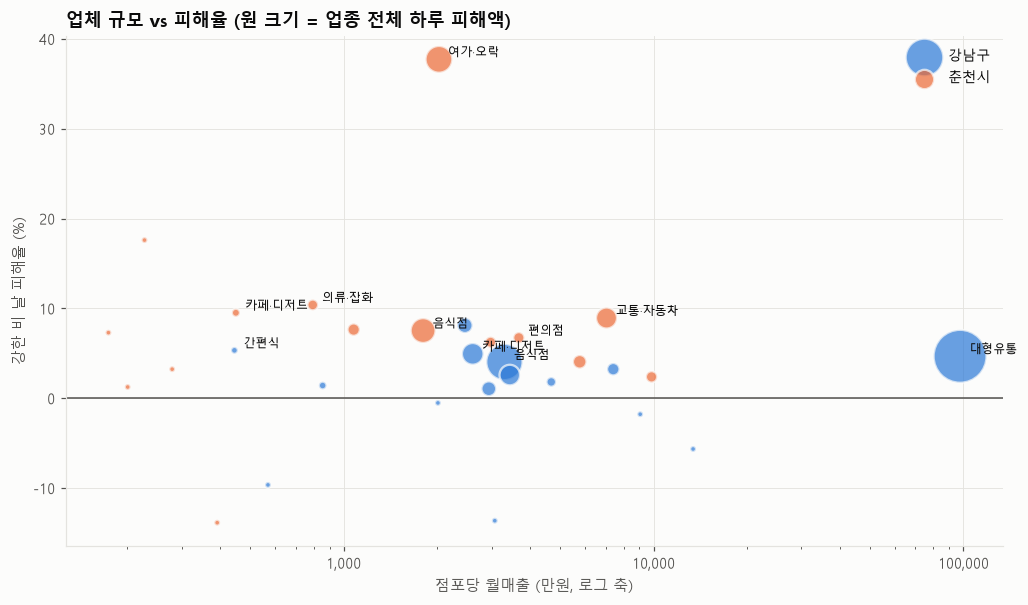

In [18]:
fig, ax = plt.subplots(figsize=(9.5, 5.6))
for r in REGIONS:
    d = dm[dm['region'] == r]
    size = np.clip(d['하루 피해액(백만원)'].clip(lower=0) / dm['하루 피해액(백만원)'].max() * 1200, 15, 1200)
    ax.scatter(d['점포당 월매출(만원)'], d['피해율(%)'], s=size, color=REGION_COLOR[r], alpha=0.7,
               edgecolor=SURFACE, linewidth=1.5, label=r)
    for _, row in d.iterrows():
        if row['sig'] or row['순위_금액'] <= 5:
            ax.annotate(row['industry_group'], (row['점포당 월매출(만원)'], row['피해율(%)']), textcoords='offset points',
                        xytext=(6, 2), fontsize=8, color=INK)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.axhline(0, color=INK2, lw=1)
ax.set_xlabel('점포당 월매출 (만원, 로그 축)'); ax.set_ylabel('강한 비 날 피해율 (%)')
ax.set_title('업체 규모 vs 피해율 (원 크기 = 업종 전체 하루 피해액)')
ax.legend(loc='upper right')
fig.tight_layout()

**해석 — 가설 1·2**
- 피해 **금액** 순위와 피해**율** 순위의 상관은 0.54로, 상당 부분 어긋난다.
  - **강남 대형유통**: 강한 비 날 하루 피해액 **1위**(약 6.8억원, 신한카드 기준)지만 피해율은 4.7%로 **14위**이고 통계적으로 유의하지도 않다. 점포당 하루 피해는 약 150만원이지만 점포당 월매출이 약 9.7억원이라 타격은 작다.
  - **춘천 여가·오락**: 피해율 **37.7%로 1위**. 점포당 하루 피해는 25만원이지만 매출의 3분의 1 이상이 사라진다.
  - **춘천 주점·유흥**: 피해율 2위(17.6%)지만 금액으로는 21위라 금액 기준이면 지원 대상에서 밀린다.
- → **가설 1**: 같은 피해 금액이라도 업체 규모에 따라 타격(피해율)이 전혀 다르다는 것이 업종 단위에서도 확인된다.
- → **가설 2**: 피해 금액 순으로 지원하면 **대형 업종에 예산이 몰리고, 매출의 큰 몫을 잃는 소규모 업종은 뒤로 밀린다.** 지원 기준에 피해율(또는 피해액 ÷ 매출)을 넣어야 한다는 근거다. 실제 배분 효과는 6단계(지원금 최적화)에서 비교한다.
- 일부 업종은 효과가 양수(비 오는 날 매출 증가)로 나와 피해액이 음수다. 이들은 지원 대상이 아니다.

### 8-1. 무엇이 피해율을 키우나 — 구조 요인과의 관계
업종의 구조적 특성(외지 고객 비중, 체인 비중, 점포 규모)과 강한 비 피해율의 순위 상관을 본다 (30개 단위, 탐색용).

In [19]:
og = origin[origin['customer_origin'] != '미상'].groupby(['region', 'industry_group', 'customer_origin'], observed=True)['amount'].sum().unstack()
og['외지 비중'] = og['외지'] / og.sum(axis=1)
struct = dm.merge(og['외지 비중'].reset_index(), on=['region', 'industry_group']).merge(
    store[['region', 'industry_group', 'chain_share']], on=['region', 'industry_group'])
struct['독립점포 비중'] = 1 - struct['chain_share']
rows = []
for f in ['외지 비중', '독립점포 비중', '점포당 월매출(만원)']:
    for scope, d in [('전체 30개', struct), ('춘천 15개', struct[struct['region'] == '춘천시']), ('강남 15개', struct[struct['region'] == '강남구'])]:
        rho, p = spearmanr(d[f], d['피해율(%)'])
        rows.append({'요인': f, '범위': scope, '스피어만 ρ': rho, 'p값': p})
pd.DataFrame(rows).pivot(index='요인', columns='범위', values=['스피어만 ρ', 'p값']).round(2)

스피어만 ρ                   p값              
범위          강남 15개 전체 30개 춘천 15개 강남 15개 전체 30개 춘천 15개
요인                                                   
독립점포 비중      -0.76  -0.16  -0.17   0.00   0.39   0.54
외지 비중         0.04  -0.13   0.47   0.90   0.51   0.08
점포당 월매출(만원)  -0.10  -0.20   0.01   0.73   0.29   0.97

**해석**
- **춘천 안에서는 외지 고객 비중이 높은 업종일수록 강한 비 피해율이 크다** (ρ = 0.47, p = 0.08 — 업종 15개라 경계선). 5-4절의 외지 이탈 경로와 같은 방향이다.
- 점포 규모(점포당 월매출)와 피해율은 관계가 없다 (ρ ≈ 0). 즉 **피해율은 규모가 아니라 업종의 수요 구조**에서 나온다.
- 강남의 '독립점포 비중이 높을수록 피해율이 낮다'(ρ = −0.76)는 결과는, 강남 업종 효과가 대부분 유의하지 않은 작은 값이라 해석을 보류한다.

## 9. 기상 변수 간 상관 — 데이터 엔지니어링 필요성 판단
피해 예측 모델에 기상 변수를 넣을 때 서로 너무 비슷한 변수가 있는지 확인한다.

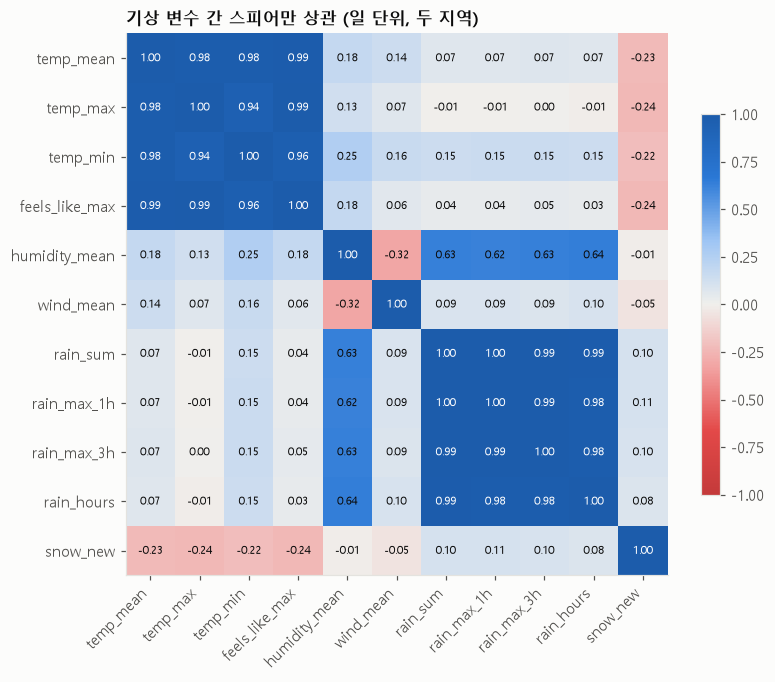

In [20]:
wd = load('weather_daily')
vars_ = ['temp_mean', 'temp_max', 'temp_min', 'feels_like_max', 'humidity_mean', 'wind_mean',
         'rain_sum', 'rain_max_1h', 'rain_max_3h', 'rain_hours', 'snow_new']
corr = wd[vars_].corr(method='spearman')
fig, ax = plt.subplots(figsize=(7.5, 6.2))
im = ax.imshow(corr.values, cmap=DIV, vmin=-1, vmax=1)
ax.set_xticks(range(len(vars_)), vars_, rotation=45, ha='right'); ax.set_yticks(range(len(vars_)), vars_)
ax.grid(False)
for i in range(len(vars_)):
    for j in range(len(vars_)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr.values[i, j]) > 0.7 else INK)
ax.set_title('기상 변수 간 스피어만 상관 (일 단위, 두 지역)', fontsize=11)
fig.colorbar(im, ax=ax, shrink=0.7)
fig.tight_layout()

**해석 — 데이터 엔지니어링이 필요한가: 필요하다 (4단계 진행 권장)**
- **기온 계열**(평균·최고·최저기온, 체감온도)은 서로 상관 0.94~0.99, **강수 계열**(일강수량, 1시간·3시간 최대, 강수 시간)은 0.98~1.00이다. 그대로 모두 넣으면 같은 정보를 중복으로 넣게 된다 → **계열별 대표 변수를 고르거나 구간화**해야 한다.
- 습도는 비와 0.63 상관이라, 폭염 판정은 습도를 이미 반영한 **체감온도 하나**로 충분하다.
- EDA에서 확인한 신호를 모델이 쓰려면 변수를 새로 만들어야 한다:
  - **시간대별 강수** (5-2절: 비가 온 시간대의 매출이 줄어듦)
  - **전날 비·연속 강수일** (기간 간 효과)
  - **기상 × 지역 / 업종 / 고객 출신** 상호작용 (춘천·외지·업종별 차이)
  - **지역·업종 인코딩**, 평년 대비 편차, 최근 매출 수준(지난주 같은 요일 등)

## 10. 정리

### EDA 핵심 결과
| 질문 | 답 | 근거 |
|---|---|---|
| 달력을 통제해도 기상 효과가 남나? | **비는 남고(특히 춘천), 폭염은 사라진다** | 3·4절: 폭염 효과는 휴가철 효과 |
| 비는 얼마나? | 춘천 보통 비 −5.6%, 강한 비 −7.2%, 비가 많을수록 커짐 | 4·5-1절 |
| 언제? | 비가 **내리는 시간대**의 매출이 줄어듦 (춘천 저녁 −10%) | 5-2절 |
| 누구에게서? | 춘천 **외지 고객 −20%** vs 현지 −4% | 5-4절 |
| 업종마다 다른가? | 춘천 여가·오락 −38% 등 비 피해 집중, 강남 대형유통은 폭염에 +16% (소비 이동) | 6절 |
| 겨울 기상은? | 폭설 사건 날 −7~−10%, 업종별 방향이 지역마다 다름 (숙박 강남 + / 춘천 −) | 7절 (사건 단위, 참고) |

### 가설 점검 (EDA 단계)
| 가설 | EDA 결과 | 다음 단계에서 할 일 |
|---|---|---|
| **1. 같은 피해액이라도 규모에 따라 타격이 다르다** | 피해액 순위 ≠ 피해율 순위 (ρ = 0.54). 강남 대형유통은 피해액 1위·피해율 14위 | 피해 예측 모델로 업종별 **피해액·피해율**을 정량화 |
| **2. 동일 지원은 비효율적이다** | 금액 기준이면 피해율이 큰 소규모 업종(춘천 여가·오락·주점 등)이 밀림 | 지원금 최적화에서 **금액 기준 vs 피해율·취약도 기준** 배분 비교 |
| **3. 기상 유형별로 업종 피해가 다르다** | 비 → 춘천 외출·방문 업종 감소 / 폭염 → 실내 대형 업종으로 이동 / 같은 업종도 기상 유형에 따라 방향 반전 | 모델에 **기상 × 업종** 상호작용 반영, 눈·한파는 사건 분석으로 보완 |

### 다음 단계
- **데이터 엔지니어링(`ana-engin`) 진행**: 기상 변수 정리(계열별 대표 변수·구간), 시간대별 강수, 전날 비, 지역·업종 인코딩, 기상 × 지역·업종·고객 상호작용, 최근 매출 수준 변수
- 한계: 기간 6개월·2개 지역, 눈·한파 표본 2~3일, 금액은 신한카드 기준